# A题问题1：AABB + GJK + 并查集 + BFS

1. 将 Excel 每一行按给定两端点建成一个半径为 30 nm 的有限直圆柱；
2. 预先构造每个圆柱的精确 AABB；
3. AABB 距离大于 1.8 nm 的介质对直接排除；
4. 其余候选对使用 GJK 求两个有限圆柱的距离；
5. 使用并查集判断左右电极是否处于同一连通分量；
6. BFS 只用于恢复并展示一条导通路径。

截断边界按原对话提供两种开关：

- `periodic_images`：默认模式，对第二个圆柱枚举 `{-L,0,L}^3` 共27个周期镜像；
- `direct`：认为附件坐标已经完成边界处理，只计算当前盒内的普通欧氏距离。


In [ ]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass
from itertools import combinations, product
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 全部长度单位均为 nm
BOX_LENGTH = 10000.0
BOX_HALF = BOX_LENGTH / 2
CYLINDER_LENGTH = 5000.0
CYLINDER_RADIUS = 30.0
CONDUCTION_THRESHOLD = 1.8

BOUNDARY_MODE = "direct"  # 可选："periodic_images" / "direct"

GJK_TOL = 1e-9
GJK_MAX_ITERATIONS = 128


def find_excel_file() -> Path:
    candidates = [p for p in Path.cwd().glob("*.xlsx") if not p.name.startswith("~$")]
    preferred = [p for p in candidates if "附件" in p.stem]
    if preferred:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError("当前目录中没有找到唯一的 Excel 附件。")


EXCEL_PATH = find_excel_file()
print("读取附件：", EXCEL_PATH.resolve())
print("边界模式：", BOUNDARY_MODE)

读取附件： E:\华数杯\2026年第七届华数杯数学建模竞赛赛题\A题 微构体中填充导电介质的仿真优化\附件.xlsx
边界模式： direct


## 1. 读取数据

附件前两行为表头，之后每一行提供圆柱轴的两个端点。

In [10]:
def load_workbook(path: Path) -> Dict[str, pd.DataFrame]:
    raw_sheets = pd.read_excel(path, sheet_name=None, header=None, engine="openpyxl")
    sheets: Dict[str, pd.DataFrame] = {}
    coordinate_names = ["x1", "y1", "z1", "x2", "y2", "z2"]

    for sheet_name, raw in raw_sheets.items():
        data = raw.iloc[2:, :6].copy()
        data.columns = coordinate_names
        data = data.dropna(how="any").astype(float).reset_index(drop=True)
        data["excel_row"] = np.arange(3, 3 + len(data))
        data["medium_label"] = [f"A{i+1}" for i in range(len(data))]
        sheets[sheet_name] = data
    return sheets


workbook = load_workbook(EXCEL_PATH)

input_summary = []
for sheet_name, df in workbook.items():
    p = df[["x1", "y1", "z1"]].to_numpy(float)
    q = df[["x2", "y2", "z2"]].to_numpy(float)
    lengths = np.linalg.norm(q - p, axis=1)
    input_summary.append({
        "分组": sheet_name,
        "Excel数据行数": len(df),
        "轴长约为5000的行数": int(np.isclose(lengths, CYLINDER_LENGTH, atol=1e-6).sum()),
        "轴长小于5000的行数": int((lengths < CYLINDER_LENGTH - 1e-6).sum()),
        "最短轴长/nm": float(lengths.min()),
        "最长轴长/nm": float(lengths.max()),
    })

display(pd.DataFrame(input_summary))

,分组,Excel数据行数,轴长约为5000的行数,轴长小于5000的行数,最短轴长/nm,最长轴长/nm
0,组1,12,2,10,1019.117255,5000.0
1,组2,49,11,38,577.473950,5000.0
2,组3,535,155,380,525.697382,5000.0


## 2. 有限圆柱的精确 AABB 与支持函数

设圆柱轴端点为 `p,q`，轴单位向量为

$
u=\frac{q-p}{\|q-p\|},
$

圆柱中心为 `c=(p+q)/2`，半轴长为 `h=|q-p|/2`。圆柱在第 `k` 个坐标方向上的
AABB 半宽为

$
e_k=h|u_k|+r\sqrt{1-u_k^2}.
$

GJK 所需的圆柱支持函数为

$
s_C(d)=c+h\operatorname{sgn}(d\cdot u)u
+r\frac{d-(d\cdot u)u}{\|d-(d\cdot u)u\|}.
$

In [11]:
class FiniteCylinder:
    def __init__(self, p: np.ndarray, q: np.ndarray, radius: float = CYLINDER_RADIUS):
        self.p = np.asarray(p, dtype=float)
        self.q = np.asarray(q, dtype=float)
        self.radius = float(radius)

        vector = self.q - self.p
        self.length = float(np.linalg.norm(vector))
        if self.length <= 0:
            raise ValueError("圆柱轴长必须大于0。")

        self.u = vector / self.length
        self.center = 0.5 * (self.p + self.q)
        self.half_length = 0.5 * self.length

        radial_extent = self.radius * np.sqrt(np.maximum(0.0, 1.0 - self.u**2))
        extent = self.half_length * np.abs(self.u) + radial_extent
        self.aabb_min = self.center - extent
        self.aabb_max = self.center + extent

    def support(self, direction: np.ndarray) -> np.ndarray:
        d = np.asarray(direction, dtype=float)
        axial_component = float(np.dot(d, self.u))
        radial_direction = d - axial_component * self.u
        radial_norm = float(np.linalg.norm(radial_direction))

        axial_point = self.half_length * self.u if axial_component >= 0 else -self.half_length * self.u
        if radial_norm <= 1e-14:
            radial_point = np.zeros(3)
        else:
            radial_point = self.radius * radial_direction / radial_norm
        return self.center + axial_point + radial_point


def dataframe_to_cylinders(df: pd.DataFrame) -> List[FiniteCylinder]:
    cylinders = []
    for _, row in df.iterrows():
        p = row[["x1", "y1", "z1"]].to_numpy(float)
        q = row[["x2", "y2", "z2"]].to_numpy(float)
        cylinders.append(FiniteCylinder(p, q))
    return cylinders


def aabb_distance_for_shifts(
    cylinder_a: FiniteCylinder,
    cylinder_b: FiniteCylinder,
    shifts: np.ndarray,
) -> np.ndarray:
    """A 与 B 的多个平移镜像之间的 AABB 距离。"""
    b_min = cylinder_b.aabb_min[None, :] + shifts
    b_max = cylinder_b.aabb_max[None, :] + shifts
    gap = np.maximum(
        0.0,
        np.maximum(cylinder_a.aabb_min[None, :] - b_max,
                   b_min - cylinder_a.aabb_max[None, :]),
    )
    return np.linalg.norm(gap, axis=1)


ZERO_SHIFT = np.zeros((1, 3), dtype=float)
PERIODIC_SHIFTS = np.asarray(
    sorted(
        ([kx * BOX_LENGTH, ky * BOX_LENGTH, kz * BOX_LENGTH]
         for kx, ky, kz in product((-1, 0, 1), repeat=3)),
        key=lambda shift: np.dot(shift, shift),
    ),
    dtype=float,
)


def shifts_for_mode(boundary_mode: str) -> np.ndarray:
    if boundary_mode == "periodic_images":
        return PERIODIC_SHIFTS
    if boundary_mode == "direct":
        return ZERO_SHIFT
    raise ValueError("boundary_mode 必须是 'periodic_images' 或 'direct'。")


print("周期镜像数量：", len(PERIODIC_SHIFTS))

周期镜像数量： 27


## 3. GJK 距离判定

对两个凸体 `A,B`，GJK 在 Minkowski 差 `A-B` 上迭代。支持点同时保存
`(a-b,a,b)`，因此能够恢复两个物体上的见证点。

当前单纯形到原点的最近点为 `v` 时：

- `upper = ||v||` 是距离上界；
- 取 `w=support(A-B,-v)` 后，
  `lower=max(0,v·w/||v||)` 是距离下界。

因而 `upper<=1.8` 可以立即确认导通，`lower>1.8` 可以立即确认不导通。

In [12]:
@dataclass
class SupportPoint:
    w: np.ndarray
    point_a: np.ndarray
    point_b: np.ndarray


@dataclass
class GJKResult:
    lower_bound: float
    upper_bound: float
    point_a: np.ndarray
    point_b: np.ndarray
    iterations: int
    status: str

    @property
    def distance(self) -> float:
        return self.upper_bound


def closest_point_on_simplex(simplex: Sequence[SupportPoint]):
    """枚举所有至多4点的面，求原点到单纯形凸包的最近点。"""
    points = np.asarray([item.w for item in simplex])
    best = None

    for size in range(1, min(4, len(simplex)) + 1):
        for index_tuple in combinations(range(len(simplex)), size):
            indices = np.asarray(index_tuple, dtype=int)
            face = points[indices]
            gram = face @ face.T
            kkt = np.block([
                [gram, np.ones((size, 1))],
                [np.ones((1, size)), np.zeros((1, 1))],
            ])
            rhs = np.r_[np.zeros(size), 1.0]
            lambdas = np.linalg.lstsq(kkt, rhs, rcond=None)[0][:size]

            if np.min(lambdas) < -1e-9:
                continue
            lambdas = np.maximum(lambdas, 0.0)
            lambdas /= lambdas.sum()
            closest = lambdas @ face
            value = float(np.dot(closest, closest))

            if best is None or value < best[0]:
                best = value, indices, lambdas, closest

    if best is None:
        raise RuntimeError("无法求得 GJK 单纯形的最近点。")

    _, indices, lambdas, closest = best
    point_a = sum(lambdas[k] * simplex[index].point_a for k, index in enumerate(indices))
    point_b = sum(lambdas[k] * simplex[index].point_b for k, index in enumerate(indices))
    return closest, indices, point_a, point_b


def gjk_distance(
    cylinder_a: FiniteCylinder,
    cylinder_b: FiniteCylinder,
    shift_b: np.ndarray = np.zeros(3),
    threshold: Optional[float] = None,
    max_iterations: int = GJK_MAX_ITERATIONS,
) -> GJKResult:
    shift_b = np.asarray(shift_b, dtype=float)

    def minkowski_support(direction: np.ndarray) -> SupportPoint:
        point_a = cylinder_a.support(direction)
        point_b = cylinder_b.support(-direction) + shift_b
        return SupportPoint(point_a - point_b, point_a, point_b)

    direction = cylinder_b.center + shift_b - cylinder_a.center
    if np.linalg.norm(direction) <= 1e-14:
        direction = np.array([1.0, 0.0, 0.0])

    simplex = [minkowski_support(direction)]
    point_a = simplex[0].point_a
    point_b = simplex[0].point_b
    lower_bound = 0.0

    for iteration in range(1, max_iterations + 1):
        closest, active, point_a, point_b = closest_point_on_simplex(simplex)
        simplex = [simplex[index] for index in active]

        upper_bound = float(np.linalg.norm(closest))
        if upper_bound <= 1e-12:
            return GJKResult(0.0, 0.0, point_a, point_b, iteration, "intersect")
        if threshold is not None and upper_bound <= threshold + 1e-10:
            return GJKResult(lower_bound, upper_bound, point_a, point_b,
                             iteration, "threshold_connected")

        new_point = minkowski_support(-closest)
        lower_bound = max(0.0, float(np.dot(closest, new_point.w) / upper_bound))
        if threshold is not None and lower_bound > threshold + 1e-10:
            return GJKResult(lower_bound, upper_bound, point_a, point_b,
                             iteration, "threshold_separated")

        duplicate = any(np.linalg.norm(new_point.w - old.w) <= 1e-9 for old in simplex)
        if upper_bound - lower_bound <= GJK_TOL * max(1.0, upper_bound) or duplicate:
            return GJKResult(lower_bound, upper_bound, point_a, point_b,
                             iteration, "converged")

        simplex.append(new_point)

    return GJKResult(lower_bound, float(np.linalg.norm(point_a - point_b)),
                     point_a, point_b, max_iterations, "max_iterations")

### GJK 与 AABB 单元测试

In [13]:
def run_geometry_tests() -> pd.DataFrame:
    a = FiniteCylinder(np.array([-50.0, 0.0, 0.0]), np.array([50.0, 0.0, 0.0]))

    # 平行圆柱：轴距100，表面距离100-2×30=40
    b = FiniteCylinder(np.array([-50.0, 100.0, 0.0]), np.array([50.0, 100.0, 0.0]))
    parallel = gjk_distance(a, b).distance
    assert abs(parallel - 40.0) < 1e-5

    # 同轴端盖相隔10
    c = FiniteCylinder(np.array([60.0, 0.0, 0.0]), np.array([160.0, 0.0, 0.0]))
    coaxial = gjk_distance(a, c).distance
    assert abs(coaxial - 10.0) < 1e-5

    # 实体相交
    d = FiniteCylinder(np.array([-50.0, 20.0, 0.0]), np.array([50.0, 20.0, 0.0]))
    overlap = gjk_distance(a, d).distance
    assert overlap < 1e-7

    # 周期镜像测试：B本体相距很远，平移-10000后与A相距10
    e = FiniteCylinder(np.array([10060.0, 0.0, 0.0]), np.array([10160.0, 0.0, 0.0]))
    periodic = gjk_distance(a, e, shift_b=np.array([-10000.0, 0.0, 0.0])).distance
    assert abs(periodic - 10.0) < 1e-5

    # AABB 向量化接口
    aabb_values = aabb_distance_for_shifts(a, e, np.array([[0.0, 0.0, 0.0], [-10000.0, 0.0, 0.0]]))
    assert aabb_values[0] > 9000
    assert abs(aabb_values[1] - 10.0) < 1e-5

    return pd.DataFrame({
        "测试": ["平行侧面", "同轴端盖", "相交", "周期镜像", "周期AABB"],
        "计算结果/nm": [parallel, coaxial, overlap, periodic, aabb_values[1]],
    })


display(run_geometry_tests())

,测试,计算结果/nm
0,平行侧面,40.0
1,同轴端盖,10.0
2,相交,0.0
3,周期镜像,10.0
4,周期AABB,10.0


## 4. 并查集主判定与 BFS 路径恢复

In [14]:
class UnionFind:
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x: int) -> int:
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a: int, b: int) -> bool:
        root_a, root_b = self.find(a), self.find(b)
        if root_a == root_b:
            return False
        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a
        self.parent[root_b] = root_a
        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1
        return True

    def connected(self, a: int, b: int) -> bool:
        return self.find(a) == self.find(b)


def add_edge(adjacency: List[set], a: int, b: int):
    adjacency[a].add(b)
    adjacency[b].add(a)


def bfs_path(adjacency: Sequence[set], source: int, target: int) -> Optional[List[int]]:
    previous = {source: None}
    queue = deque([source])

    while queue:
        node = queue.popleft()
        if node == target:
            break
        for neighbor in sorted(adjacency[node]):
            if neighbor not in previous:
                previous[neighbor] = node
                queue.append(neighbor)

    if target not in previous:
        return None

    path = []
    node: Optional[int] = target
    while node is not None:
        path.append(node)
        node = previous[node]
    return path[::-1]


def edge_key(a: int, b: int) -> Tuple[int, int]:
    return (a, b) if a < b else (b, a)


@dataclass
class SheetResult:
    sheet_name: str
    data: pd.DataFrame
    cylinders: List[FiniteCylinder]
    boundary_mode: str
    conductive: bool
    path: Optional[List[int]]
    adjacency: List[set]
    edge_info: Dict[Tuple[int, int], dict]
    left_node: int
    right_node: int
    pairs_with_aabb_candidate: int
    aabb_image_candidates: int
    gjk_calls: int
    gjk_uncertain: int


def solve_sheet(
    sheet_name: str,
    df: pd.DataFrame,
    boundary_mode: str = BOUNDARY_MODE,
    threshold: float = CONDUCTION_THRESHOLD,
) -> SheetResult:
    cylinders = dataframe_to_cylinders(df)
    shifts = shifts_for_mode(boundary_mode)
    n = len(cylinders)
    left_node, right_node = n, n + 1

    if boundary_mode == "periodic_images":
        # 当前数据中每个圆柱AABB在各轴的跨度都小于一个周期，故±1周期镜像足够。
        for index, cylinder in enumerate(cylinders):
            span = cylinder.aabb_max - cylinder.aabb_min
            if np.any(span >= BOX_LENGTH - 1e-9):
                raise ValueError(
                    f"A{index+1} 的AABB跨度达到一个周期；仅枚举27镜像可能不足。"
                )

    dsu = UnionFind(n + 2)
    adjacency = [set() for _ in range(n + 2)]
    edge_info: Dict[Tuple[int, int], dict] = {}

    # 电极连接必须单独判断，不使用周期镜像。
    for i, cylinder in enumerate(cylinders):
        left_distance = max(0.0, float(cylinder.aabb_min[0] + BOX_HALF))
        right_distance = max(0.0, float(BOX_HALF - cylinder.aabb_max[0]))

        if left_distance <= threshold + 1e-10:
            dsu.union(left_node, i)
            add_edge(adjacency, left_node, i)
            edge_info[edge_key(left_node, i)] = {
                "type": "左电极", "distance": left_distance, "shift": np.zeros(3)
            }
        if right_distance <= threshold + 1e-10:
            dsu.union(right_node, i)
            add_edge(adjacency, right_node, i)
            edge_info[edge_key(right_node, i)] = {
                "type": "右电极", "distance": right_distance, "shift": np.zeros(3)
            }

    pairs_with_aabb_candidate = 0
    aabb_image_candidates = 0
    gjk_calls = 0
    gjk_uncertain = 0

    for i in range(n):
        for j in range(i + 1, n):
            aabb_distances = aabb_distance_for_shifts(cylinders[i], cylinders[j], shifts)
            candidate_indices = np.flatnonzero(aabb_distances <= threshold + 1e-12)
            if len(candidate_indices) == 0:
                continue

            pairs_with_aabb_candidate += 1
            aabb_image_candidates += len(candidate_indices)
            # 优先检查AABB距离最小的周期镜像。
            candidate_indices = candidate_indices[np.argsort(aabb_distances[candidate_indices])]

            connected_info = None
            for shift_index in candidate_indices:
                shift = shifts[shift_index]
                gjk = gjk_distance(cylinders[i], cylinders[j], shift_b=shift, threshold=threshold)
                gjk_calls += 1

                certified_connected = gjk.upper_bound <= threshold + 1e-9
                certified_separated = gjk.lower_bound > threshold + 1e-9
                if not certified_connected and not certified_separated and gjk.status == "max_iterations":
                    gjk_uncertain += 1
                    warnings.warn(
                        f"{sheet_name}: A{i+1}-A{j+1} 在镜像 {tuple(shift)} 下GJK未完全收敛。"
                    )

                if certified_connected:
                    connected_info = {
                        "type": "介质-介质",
                        "distance": gjk.upper_bound,
                        "lower_bound": gjk.lower_bound,
                        "shift": shift.copy(),
                        "point_i": gjk.point_a,
                        "point_j_image": gjk.point_b,
                        "gjk_iterations": gjk.iterations,
                        "gjk_status": gjk.status,
                    }
                    break

            if connected_info is not None:
                dsu.union(i, j)
                add_edge(adjacency, i, j)
                edge_info[edge_key(i, j)] = connected_info

    conductive = dsu.connected(left_node, right_node)  # 主判据
    path = bfs_path(adjacency, left_node, right_node)   # 仅用于展示
    assert conductive == (path is not None), "并查集与BFS结果不一致。"

    return SheetResult(
        sheet_name=sheet_name,
        data=df,
        cylinders=cylinders,
        boundary_mode=boundary_mode,
        conductive=conductive,
        path=path,
        adjacency=adjacency,
        edge_info=edge_info,
        left_node=left_node,
        right_node=right_node,
        pairs_with_aabb_candidate=pairs_with_aabb_candidate,
        aabb_image_candidates=aabb_image_candidates,
        gjk_calls=gjk_calls,
        gjk_uncertain=gjk_uncertain,
    )


def node_label(result: SheetResult, node: int) -> str:
    if node == result.left_node:
        return "L(左电极)"
    if node == result.right_node:
        return "R(右电极)"
    row = result.data.iloc[node]
    return f"{row['medium_label']}(Excel第{int(row['excel_row'])}行)"


def path_table(result: SheetResult) -> pd.DataFrame:
    if result.path is None:
        return pd.DataFrame()

    rows = []
    for order, (a, b) in enumerate(zip(result.path[:-1], result.path[1:]), start=1):
        info = result.edge_info[edge_key(a, b)]
        rows.append({
            "序号": order,
            "从": node_label(result, a),
            "到": node_label(result, b),
            "连接类型": info["type"],
            "距离上界/nm": info["distance"],
            "第二介质采用的周期平移/nm": tuple(np.asarray(info["shift"], dtype=int)),
        })
    return pd.DataFrame(rows)

## 5. 计算三组微构体

In [15]:
results: Dict[str, SheetResult] = {}
for sheet_name, df in workbook.items():
    print(f"正在计算 {sheet_name} ...")
    results[sheet_name] = solve_sheet(sheet_name, df, BOUNDARY_MODE)

summary = []
for sheet_name, result in results.items():
    path_text = "无" if result.path is None else " → ".join(node_label(result, node) for node in result.path)
    summary.append({
        "分组": sheet_name,
        "圆柱节点数": len(result.cylinders),
        "边界模式": result.boundary_mode,
        "有AABB候选镜像的介质对": result.pairs_with_aabb_candidate,
        "AABB候选镜像总数": result.aabb_image_candidates,
        "GJK调用数": result.gjk_calls,
        "GJK未决数": result.gjk_uncertain,
        "并查集判定": "导通" if result.conductive else "不导通",
        "BFS展示路径": path_text,
    })

result_summary = pd.DataFrame(summary)
display(result_summary)

for sheet_name, result in results.items():
    print(f"\n{sheet_name}：{'导通' if result.conductive else '不导通'}")
    if result.path is not None:
        display(path_table(result))

正在计算 组1 ...
正在计算 组2 ...
正在计算 组3 ...


,分组,圆柱节点数,边界模式,有AABB候选镜像的介质对,AABB候选镜像总数,GJK调用数,GJK未决数,并查集判定,BFS展示路径
0,组1,12,direct,5,5,5,0,不导通,无
1,组2,49,direct,129,129,129,0,导通,L(左电极) → A2(Excel第4行) → A12(Excel第14行) → A24(Excel第26行) → A39(Excel第41行) → R(右电极)
2,组3,535,direct,3926,3926,3926,0,导通,L(左电极) → A63(Excel第65行) → A264(Excel第266行) → A216(Excel第218行) → A351(Excel第353行) → R(右电极)



组1：不导通

组2：导通


,序号,从,到,连接类型,距离上界/nm,第二介质采用的周期平移/nm
0,1,L(左电极),A2(Excel第4行),左电极,0.000000e+00,"(0, 0, 0)"
1,2,A2(Excel第4行),A12(Excel第14行),介质-介质,1.879218e-10,"(0, 0, 0)"
2,3,A12(Excel第14行),A24(Excel第26行),介质-介质,7.991130e-01,"(0, 0, 0)"
3,4,A24(Excel第26行),A39(Excel第41行),介质-介质,2.860973e-11,"(0, 0, 0)"
4,5,A39(Excel第41行),R(右电极),右电极,0.000000e+00,"(0, 0, 0)"



组3：导通


,序号,从,到,连接类型,距离上界/nm,第二介质采用的周期平移/nm
0,1,L(左电极),A63(Excel第65行),左电极,0.000000e+00,"(0, 0, 0)"
1,2,A63(Excel第65行),A264(Excel第266行),介质-介质,7.205900e-01,"(0, 0, 0)"
2,3,A264(Excel第266行),A216(Excel第218行),介质-介质,8.658266e-11,"(0, 0, 0)"
3,4,A216(Excel第218行),A351(Excel第353行),介质-介质,1.764680e-12,"(0, 0, 0)"
4,5,A351(Excel第353行),R(右电极),右电极,0.000000e+00,"(0, 0, 0)"


## 6. 三维路径展示

红色圆柱轴段是 BFS 找到的一条路径中的介质。周期连接的具体平移量在上方路径表中列出。

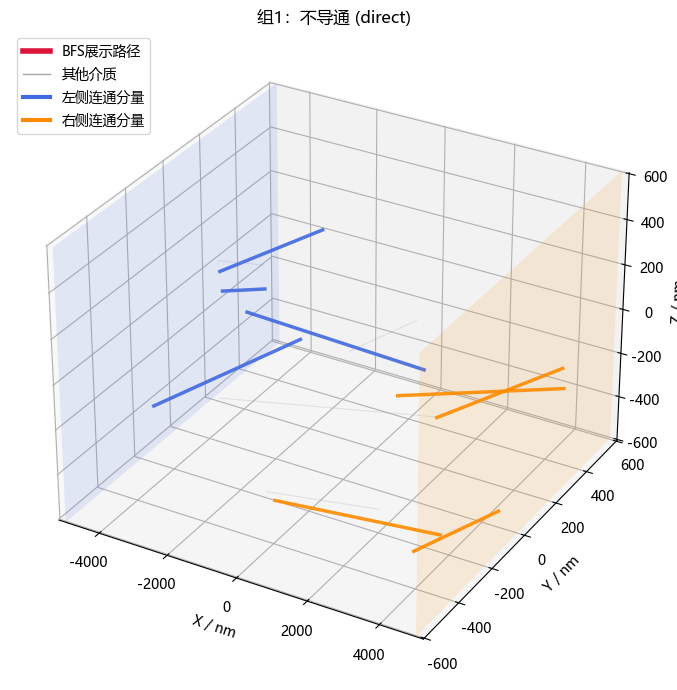

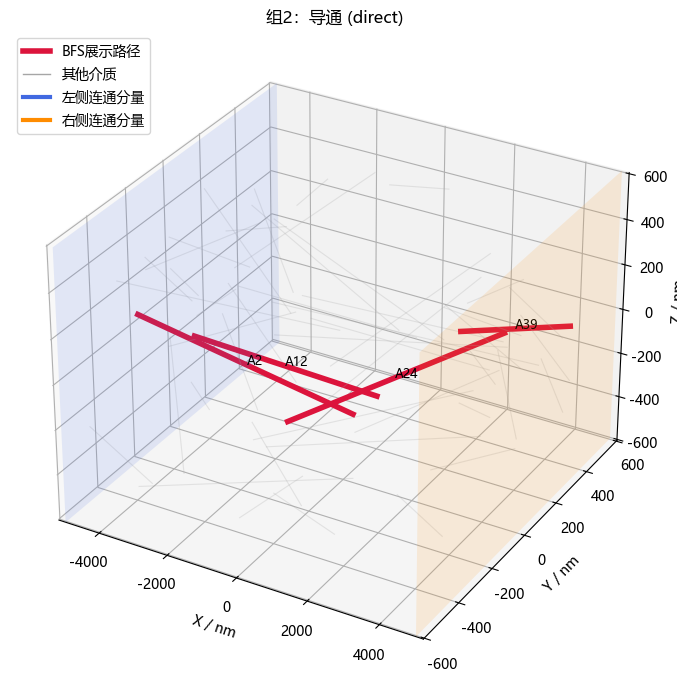

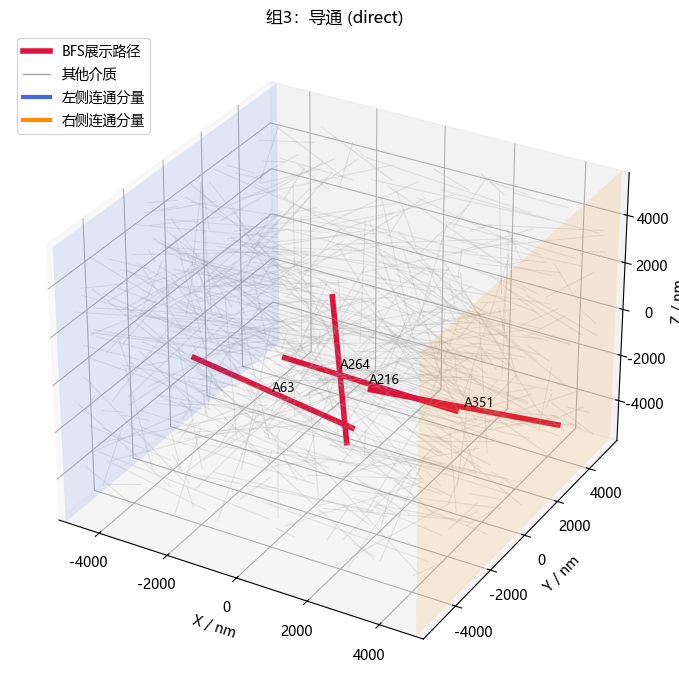

In [16]:
def reachable_nodes(adjacency: Sequence[set], source: int) -> set:
    reached = {source}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in adjacency[node]:
            if neighbor not in reached:
                reached.add(neighbor)
                queue.append(neighbor)
    return reached


def plot_sheet(result: SheetResult):
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection="3d")

    path_media = set() if result.path is None else set(result.path) - {result.left_node, result.right_node}
    left_component = reachable_nodes(result.adjacency, result.left_node)
    right_component = reachable_nodes(result.adjacency, result.right_node)

    for i, row in result.data.iterrows():
        p = row[["x1", "y1", "z1"]].to_numpy(float)
        q = row[["x2", "y2", "z2"]].to_numpy(float)

        if i in path_media:
            color, width, alpha = "crimson", 4.0, 1.0
        elif result.path is None and i in left_component:
            color, width, alpha = "royalblue", 2.5, 0.9
        elif result.path is None and i in right_component:
            color, width, alpha = "darkorange", 2.5, 0.9
        else:
            color, width, alpha = "0.65", 0.8, 0.25

        ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                color=color, lw=width, alpha=alpha)

        if i in path_media:
            center = 0.5 * (p + q)
            ax.text(center[0], center[1], center[2], row["medium_label"], fontsize=9)

    coordinates = result.data[["x1", "y1", "z1", "x2", "y2", "z2"]].to_numpy().reshape(-1, 3)
    yz_max = np.maximum(100.0, np.max(np.abs(coordinates[:, 1:]), axis=0) * 1.15 + CYLINDER_RADIUS)
    Y, Z = np.meshgrid(
        np.linspace(-yz_max[0], yz_max[0], 2),
        np.linspace(-yz_max[1], yz_max[1], 2),
    )
    for x, color in [(-BOX_HALF, "royalblue"), (BOX_HALF, "darkorange")]:
        X = np.full_like(Y, x)
        ax.plot_surface(X, Y, Z, color=color, alpha=0.12, shade=False)

    ax.set_xlim(-5200, 5200)
    ax.set_ylim(-yz_max[0], yz_max[0])
    ax.set_zlim(-yz_max[1], yz_max[1])
    ax.set_xlabel("X / nm")
    ax.set_ylabel("Y / nm")
    ax.set_zlabel("Z / nm")
    ax.set_title(
        f"{result.sheet_name}：{'导通' if result.conductive else '不导通'} "
        f"({result.boundary_mode})"
    )
    ax.legend(handles=[
        Line2D([0], [0], color="crimson", lw=4, label="BFS展示路径"),
        Line2D([0], [0], color="0.65", lw=1, label="其他介质"),
        Line2D([0], [0], color="royalblue", lw=3, label="左侧连通分量"),
        Line2D([0], [0], color="darkorange", lw=3, label="右侧连通分量"),
    ], loc="upper left")
    plt.tight_layout()
    plt.show()


for result in results.values():
    plot_sheet(result)